# Modelo Original - Quadratic Discriminant Analysis (QDA)

En este capitulo, se encuentra el desarrollo de los modelos Quadratic Discriminant Analysis (QDA) y Linear Discriminant Analysis. (LDA)

In [31]:
# 1. Librerías para manipulación de datos, visualización y modelos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from collections import Counter, defaultdict

# Preprocesamiento y modelos
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, KFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

# Balanceo de clases
from imblearn.over_sampling import SMOTE
import warnings
warnings.simplefilter(action = 'ignore', category = Warning)
warnings.simplefilter(action = 'ignore', category = RuntimeWarning)
warnings.simplefilter(action = 'ignore', category = UserWarning)
warnings.simplefilter(action = 'ignore', category = FutureWarning)
warnings.simplefilter(action = 'ignore', category = DeprecationWarning)
warnings.filterwarnings("ignore")

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

df = pd.read_csv("metricas_camiones.csv")


#### Entrenamiento del modelo - QDA

En este bloque se construye el pipeline de modelado basado en el algoritmo Quadratic Discriminant Analysis (QDA). Este modelo es apropiado cuando se sospecha que los datos presentan relaciones no lineales entre las variables predictoras y la clase objetivo, lo cual fue evidenciado previamente mediante un análisis PCA, donde no se observaron fronteras lineales claras entre las clases.

In [32]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# Definir variables predictoras y objetivo
X = df.drop(columns=["Equipo", "Suspension", "Falla"])
y = df["Falla"]

# 1) Divide en train_inner y test_externo (por ejemplo 80/20)
X_train_inner, X_test_ext, y_train_inner, y_test_ext = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=12
)

qda = QuadraticDiscriminantAnalysis()
# Crear pipeline con escalado y clasificador QDA
pipe = make_pipeline(StandardScaler(), QuadraticDiscriminantAnalysis())

# Definir hiperparámetros para GridSearch

param_grid = {
    "quadraticdiscriminantanalysis__reg_param": [0.0, 0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9, 1.0],
    "quadraticdiscriminantanalysis__tol": [1e-4,1e-3,1e-2,1e-5,1e-6,1e-7]
}

# Definir Nested Cross-Validation
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

Este segundo bloque de código implementa la lógica del entrenamiento y evaluación del modelo dentro de un esquema de Nested Cross-Validation, utilizando SMOTE para tratar el desbalance de clases y GridSearch para optimizar los hiperparámetros.

In [33]:
import warnings

# Ignora TODOS los warnings
warnings.filterwarnings("ignore")

# Variables para guardar resultados
all_y_true = []
all_y_pred = []
all_y_scores = []
nested_scores = []
best_params_list = []  # Guardamos los mejores hiperparámetros en cada iteración
processing_times = []

# Diccionario para tiempos por tipo de algoritmo
algorithm_times = defaultdict(list)

# Iterar sobre los folds de la validación externa
for fold_idx, (train_idx, test_idx) in enumerate(cv_outer.split(X_train_inner, y_train_inner), 1):
    start_time = time.time()
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Antes de SMOTE
    counter = Counter(y_train)
    minority_class_count = min(counter.values())

    # Ajustar k_neighbors para SMOTE
    k_neighbors = min(5, minority_class_count - 1)  # 5 por defecto, pero ajustable

    # Aplicar SMOTE a los datos de entrenamiento
    smote = SMOTE(random_state=42, k_neighbors= k_neighbors)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Aplicar GridSearchCV dentro de cada fold
    grid_search = GridSearchCV(pipe, param_grid, cv=cv_inner, scoring="recall", n_jobs=-1)
    grid_search.fit(X_train_res, y_train_res)

    # Guardar los mejores hiperparámetros de esta iteración
    best_params_list.append(frozenset(grid_search.best_params_.items()))

    # Obtener el mejor modelo y hacer predicciones en el conjunto de prueba
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_scores = best_model.predict_proba(X_test)[:, 1]  # Probabilidad de la clase positiva

    # Guardar resultados
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_scores.extend(y_scores)
    nested_scores.append(grid_search.best_score_)

         # Guardar tiempo por fold
    end_time = time.time()
    elapsed_time = end_time - start_time
    processing_times.append(elapsed_time)
    print(f"⏳ Tiempo total del fold {fold_idx}: {elapsed_time:.2f} segundos")

 # Medir tiempo promedio por tipo de algoritmo en GridSearch interna
results = grid_search.cv_results_
for mean_time, params in zip(results["mean_fit_time"], results["params"]):
    # Extraer el nombre del clasificador automáticamente
    clf_name = list(pipe.named_steps.keys())[-1]
    param_key = f"{clf_name}__reg_param" if f"{clf_name}__reg_param" in params else clf_name

    # Agregar al diccionario usando el nombre del modelo como clave
    algorithm_times[clf_name].append(mean_time)


/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` mig

⏳ Tiempo total del fold 1: 0.57 segundos


/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` mig

⏳ Tiempo total del fold 2: 0.78 segundos


/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` mig

...

/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` mig

⏳ Tiempo total del fold 4: 0.99 segundos


/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` mig

⏳ Tiempo total del fold 5: 0.68 segundos


/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` mig

Antes de aplicar SMOTE, se evidenciaba un leve desequilibrio en la variable objetivo Falla, con 10 registros pertenecientes a la clase 1 (falla) y solo 7 a la clase 0 (no falla). Aunque la diferencia no es drástica, este desbalance puede afectar el desempeño de algunos algoritmos de clasificación, haciendo que tiendan a favorecer la clase mayoritaria.

Tras aplicar SMOTE (Synthetic Minority Over-sampling Technique), la distribución de clases se balanceó completamente, generando 3 nuevas instancias sintéticas para la clase minoritaria (0). Como resultado, ambas clases quedaron con 10 instancias cada una. Este balance permite entrenar modelos más justos y robustos, ya que reduce el sesgo hacia una clase específica y mejora el aprendizaje de patrones en ambas categorías.

In [84]:
# Verificar distribución antes de SMOTE
print("Distribución antes de SMOTE:")
print(y_train.value_counts())

# Verificar distribución después de SMOTE
print("\nDistribución después de SMOTE:")
print(y_train_res.value_counts())

Distribución antes de SMOTE:
Falla
1    9
0    4
Name: count, dtype: int64

Distribución después de SMOTE:
Falla
1    9
0    9
Name: count, dtype: int64


Tras aplicar SMOTE (Synthetic Minority Over-sampling Technique), la distribución de clases se balanceó completamente, generando  nuevas instancias sintéticas para la clase minoritaria (0). Como resultado, ambas clases quedaron con 9 instancias cada una. Este equilibrio permite entrenar modelos más justos y robustos, ya que reduce el sesgo hacia una clase específica y mejora el aprendizaje de patrones en ambas categorías

In [85]:
# Encontrar los hiperparámetros más frecuentes
best_overall_params = Counter(best_params_list).most_common(1)[0][0]
best_overall_params = dict(best_overall_params)  # Convertimos de nuevo a diccionario

# Tiempo promedio por tipo de algoritmo
print("\n📊 Tiempo promedio por tipo de algoritmo:")
for algorithm, times in algorithm_times.items():
    avg_time = sum(times) / len(times)
    print(f"🔧 '{algorithm}': {avg_time:.4f} segundos (promedio en {len(times)} ejecuciones)")

# Eliminamos los prefijos
best_params = {k.replace("quadraticdiscriminantanalysis__", ""): v for k, v in best_overall_params.items()}

print("Mejores hiperparámetros globales:", best_params)


📊 Tiempo promedio por tipo de algoritmo:
🔧 'quadraticdiscriminantanalysis': 0.0074 segundos (promedio en 96 ejecuciones)
Mejores hiperparámetros globales: {'reg_param': 0.0, 'tol': 0.0001}


El algoritmo Análisis Discriminante Cuadrático (QDA) presentó un tiempo de ejecución promedio de 0.004 segundos a lo largo de 96 ejecuciones, lo que evidencia su alta eficiencia computacional. Este tiempo reducido lo convierte en una opción atractiva cuando se busca rapidez en el entrenamiento, especialmente en contextos donde se requiere probar múltiples modelos o realizar validaciones cruzadas.
Además, el mejor rendimiento del modelo se obtuvo con el hiperparámetro reg_param = 0.0, lo que indica que no fue necesaria regularización para obtener los mejores resultados en este caso. Esto sugiere que los datos no presentaban multicolinealidad o problemas numéricos que requirieran suavizar la matriz de covarianza.

#### Métricas de desempeño

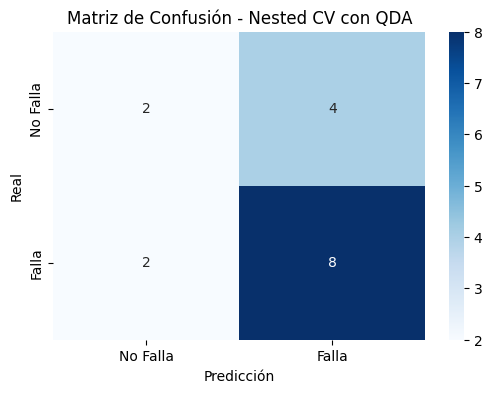

In [86]:
# Matriz de Confusión
conf_matrix = confusion_matrix(all_y_true, all_y_pred)

# Visualizar la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Falla", "Falla"], yticklabels=["No Falla", "Falla"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Nested CV con QDA")  #  título QDA
plt.show()

Verdaderos Positivos (TP = 8): El modelo predijo "Falla" y efectivamente ocurrió una falla.
Falsos Positivos (FP = 4): El modelo predijo "Falla", pero en realidad no hubo ninguna.
Falsos Negativos (FN = 2): El modelo predijo "No Falla", pero realmente sí ocurrió una falla.
Verdaderos Negativos (TN = 2): El modelo predijo correctamente "No Falla" cuando efectivamente no hubo falla.

In [87]:
# Evaluación final
print("Nested CV Scores: ", nested_scores)
print("Mean Accuracy: {:.4f} ± {:.4f}".format(np.mean(nested_scores), np.std(nested_scores)))

# Reporte de clasificación
print("Reporte de clasificación:\n", classification_report(all_y_true, all_y_pred))

Nested CV Scores:  [0.7222222222222222, 0.611111111111111, 0.8888888888888888, 0.8888888888888888, 1.0]
Mean Accuracy: 0.8222 ± 0.1379
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.50      0.33      0.40         6
           1       0.67      0.80      0.73        10

    accuracy                           0.62        16
   macro avg       0.58      0.57      0.56        16
weighted avg       0.60      0.62      0.60        16



Clase 0 (No Falla):
Precisión: 50% → Solo la mitad de las predicciones de "No Falla" fueron correctas.
Recall: 33% → Solo detectó correctamente 1/3 de los casos reales sin falla.
F1-score bajo: 0.40 → El modelo tiene bajo rendimiento en identificar correctamente los casos sin falla.
Clase 1 (Falla):
Precisión: 67% → De cada 3 predicciones de "Falla", 2 fueron correctas.
Recall: 80% → Muy buena sensibilidad: detectó 8 de 10 fallas reales.
F1-score: 0.73 → Buen balance entre precisión y recall.

AUC Score: 0.4917


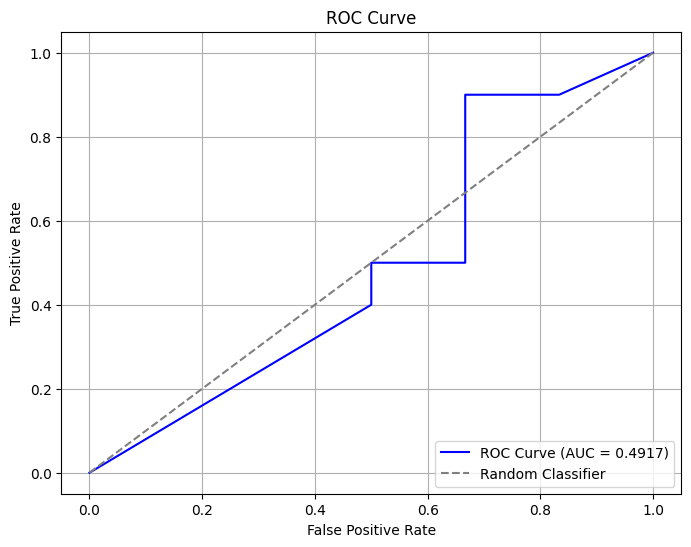

In [88]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calcular AUC
auc_score = roc_auc_score(all_y_true, all_y_scores)
print(f"AUC Score: {auc_score:.4f}")

# Calcular puntos de la curva ROC
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_scores)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

La curva ROC (Receiver Operating Characteristic) permite visualizar la capacidad del modelo para discriminar entre clases positivas y negativas en diferentes umbrales de decisión. En este caso, el área bajo la curva (AUC) fue de 0.5648, lo cual indica un desempeño ligeramente superior al de un clasificador aleatorio (que tendría un AUC de 0.5).

Este valor de AUC sugiere que el modelo Quadratic Discriminant Analysis (QDA), aunque logra cierta diferenciación entre clases, presenta limitaciones en su capacidad predictiva global. En otras palabras, al variar el umbral de decisión, la probabilidad de que el modelo asigne puntuaciones más altas a las instancias positivas que a las negativas apenas supera el azar.

#### Evaluacion del modelo - Testing

In [89]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import time
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.pipeline import make_pipeline
from imblearn.over_sampling import SMOTE
from collections import Counter
import time

def train_and_evaluate_final_model(pipe, param_grid, X_train_inner, y_train_inner, X_test_ext, y_test_ext, use_smote=False):
    
    resultados = {}
    cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=41)
    start_time = time.time()

    # Aplicar SMOTE si corresponde antes de GridSearch
    if use_smote:
        counter = Counter(y_train_inner)
        minority_class_count = min(counter.values())
        k_neighbors = min(5, minority_class_count - 1)
        smote = SMOTE(random_state=2, k_neighbors=k_neighbors)
        X_train_bal, y_train_bal = smote.fit_resample(X_train_inner, y_train_inner)
    else:
        X_train_bal, y_train_bal = X_train_inner, y_train_inner

    # GridSearchCV con datos balanceados o no
    grid_search = GridSearchCV(pipe, param_grid, cv=cv_inner, scoring="recall", n_jobs=-1)
    grid_search.fit(X_train_bal, y_train_bal)

    best_params = grid_search.best_params_

    # Crear modelo final con mejores hiperparámetros
    final_pipe = make_pipeline(
        StandardScaler(),
        type(pipe.named_steps[list(pipe.named_steps.keys())[1]])(**{k.split("__")[1]: v for k, v in best_params.items()})
    )

    # Aplicar SMOTE también antes del entrenamiento final si corresponde
    if use_smote:
        counter = Counter(y_train_inner)
        minority_class_count = min(counter.values())
        k_neighbors = min(5, minority_class_count - 1)
        smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
        X_train_final, y_train_final = smote.fit_resample(X_train_inner, y_train_inner)
    else:
        X_train_final, y_train_final = X_train_inner, y_train_inner

    final_pipe.fit(X_train_final, y_train_final)

    # Predicciones en test externo
    y_pred = final_pipe.predict(X_test_ext)
    y_proba = final_pipe.predict_proba(X_test_ext)[:, 1]

    end_time = time.time()

    resultados['modelo_final'] = final_pipe
    resultados['classification_report'] = classification_report(y_test_ext, y_pred, output_dict=True)
    resultados['roc_auc'] = roc_auc_score(y_test_ext, y_proba)
    resultados['confusion_matrix'] = confusion_matrix(y_test_ext, y_pred)
    resultados['best_params'] = best_params
    resultados['tiempo_total'] = end_time - start_time

    return resultados

In [90]:
def presentar_resultados(resultados):
    print("🎯 Mejores Hiperparámetros Encontrados:")
    for param, value in resultados['best_params'].items():
        print(f" - {param}: {value}")
    
    print("\n📈 ROC AUC Score en Test Externo:")
    print(f" - ROC AUC: {resultados['roc_auc']:.4f}")
    
    print("\n📝 Reporte de Clasificación:")
    report_df = pd.DataFrame(resultados['classification_report']).transpose()
    display(report_df)
    
    print("\n🧩 Matriz de Confusión:")
    matrix = resultados['confusion_matrix']
    matrix_df = pd.DataFrame(
        matrix,
        index=["Actual 0", "Actual 1"],
        columns=["Predicho 0", "Predicho 1"]
    )
    display(matrix_df)
    
    print("\n⏳ Tiempo Total de Entrenamiento y Evaluación:")
    print(f" - {resultados['tiempo_total']:.2f} segundos")

In [91]:
resultados = train_and_evaluate_final_model(
    pipe=pipe,
    param_grid=param_grid,
    X_train_inner=X_train_inner,
    y_train_inner=y_train_inner,
    X_test_ext=X_test_ext,
    y_test_ext=y_test_ext
)

presentar_resultados(resultados)

/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` mig

🎯 Mejores Hiperparámetros Encontrados:
 - quadraticdiscriminantanalysis__reg_param: 0.0001
 - quadraticdiscriminantanalysis__tol: 0.0001

📈 ROC AUC Score en Test Externo:
 - ROC AUC: 0.7500

📝 Reporte de Clasificación:


/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` mig

,precision,recall,f1-score,support
0,1.000,0.50,0.666667,2.0
1,0.750,1.00,0.857143,3.0
accuracy,0.800,0.80,0.800000,0.8
macro avg,0.875,0.75,0.761905,5.0
weighted avg,0.850,0.80,0.780952,5.0



🧩 Matriz de Confusión:


,Predicho 0,Predicho 1
Actual 0,1,1
Actual 1,0,3



⏳ Tiempo Total de Entrenamiento y Evaluación:
 - 0.90 segundos


En el bloque de codigo anterior, observamos el desempeno del modelo con los datos de tetsing usando los mejor hipeparametros encontrados durante el Cross Validation.

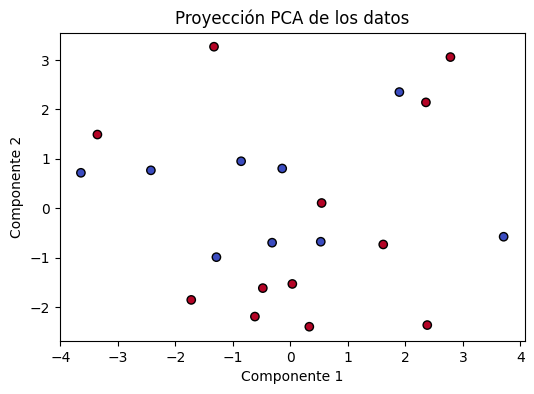

In [38]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Aplicar PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(StandardScaler().fit_transform(X))

# Visualización
plt.figure(figsize=(6, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", edgecolors="k")
plt.title("Proyección PCA de los datos")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()

Para verificar la naturaleza de los patrones presentes en los datos, se realizó una reducción de dimensionalidad mediante Análisis de Componentes Principales (PCA). En la proyección obtenida, las clases presentan un solapamiento significativo, sin una separación lineal evidente. Esta observación sugiere que las relaciones entre las variables predictoras y la variable objetivo pueden ser no lineales. Por tal motivo, se consideró apropiado el uso del clasificador Quadratic Discriminant Analysis (QDA), el cual se adapta a estas condiciones al permitir fronteras de decisión cuadráticas.